# Mackey-Glass (MG) LTSL Prediction — `offs=1` Experiments

This notebook evaluates the **LTSL (Long-Term Short-Latency)** BCPNN model on the **Mackey-Glass chaotic timeseries** (`mgdata.pkl`), focusing on **1-step-ahead prediction** (`offs=1`).

## Overview

1. **Data exploration** — Load the MG dataset and inspect the raw timeseries and derived features (value, moving mean, first derivative).
2. **Evolutionary hyperparameter search results** — Run the model with EA-optimized parameters (20 h search targeting `rmse_unseen`), visualize the delay ladder, and report RMSE on train / validation / unseen splits.
3. **Performance visualization** — Compare model RMSE against a naive persistence baseline (`y_{t+1} = y_t`).
4. **Extended experiments** — 10-step prediction (`offs=10`), parameter sweeps (heatmaps), logarithmic `K_mode` alternative, and a generation-focused EA configuration.

## Key parameters (best EA result, `offs=1`)

| Parameter | Value |
|-----------|-------|
| `K` | 8 (linear mode) |
| `mean_nbin` | 16 |
| `deriv1st_nbin` | 18 |
| `taumax` | ~0.268 |
| `trnpat` | 10840 |

Persistence baseline RMSE ≈ 0.031; best unseen RMSE ≈ 0.0267.


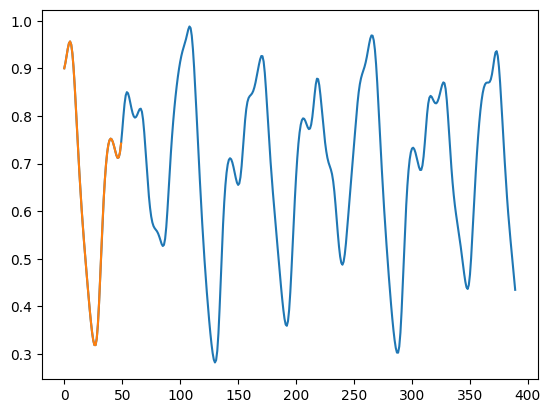

In [17]:
# --- Cell: Load and plot the Mackey-Glass timeseries ---
# Loads mgdata.pkl via FeatureGeneration and plots short segments of the raw series.
import pickle

import matplotlib.pyplot as plt
import numpy as np

import FeatureGeneration

tmax = 10000
#FeatureGeneration.sum_of_sinusoids([0.005, 0.05, .5], tmax=tmax, dt=1)
x = FeatureGeneration.timeseries_from_dataset(pickle.load(open(FeatureGeneration.dataset_path("mgdata.pkl"), "rb")))
#plt.plot(x[10:4000])
plt.plot(x[10:400])
plt.plot(x[10:60])

(np.float64(0.275367244786345), np.float64(0.9982978762211017))

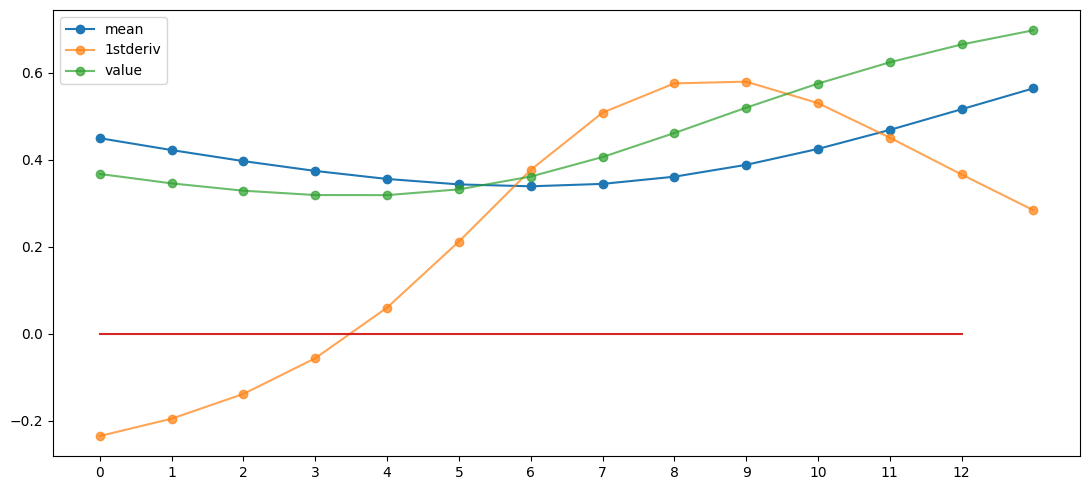

In [16]:
# --- Cell: Inspect feature construction (value, mean, 1st derivative) ---
# Builds mean/derivative features and plots a small window to show the 3-step
# lag introduced by the 7-point moving average (mean != value at same index).
#No real cause for concern yet, but worth pointing out: Mean!=Value Theres a shift by three steps due to the 7 point moving average
import FeatureGeneration
import matplotlib.pyplot as plt
import numpy as np
import Utils, pickle
tmax = 10000
cutoff = 400
timeseries_file = "mgdata.pkl"
x = FeatureGeneration.timeseries_from_dataset(pickle.load(open(FeatureGeneration.dataset_path(timeseries_file), "rb")))[:tmax]
feats = FeatureGeneration.make_mean_derivative_features(x=x, cutoff=cutoff, figno=0)
plt.figure(figsize=(11,5))
plt.plot(feats[27:41, 3],'-o', label='mean') #shifted by 3 steps due to the 7 point moving average around t?
plt.plot(feats[27:41, 1],'-o', label='1stderiv', alpha=0.7) 
plt.plot(feats[27:41, 0],'-o', label='value', alpha=0.7) 
plt.plot(np.linspace(0,12,13),np.zeros(13))
plt.xticks(np.linspace(0,12,13))
plt.legend()
plt.tight_layout()
np.min(feats[:,0]), np.max(feats[:,0])

K_mode=linear, c=None, τ_0=0.001, τ_11=0.26822566930621056
Using data from /home/fiebig/Dropbox/GIT/BCPNNSim2.2_UC2/tests/UC2-EXTRABRAIN/LTSLtest/general/datasets/mgdata.pkl (len=20000)


Hj = 1 nactHi = 12 nsilHi = 0 denHi = 12 Mi = 288 denNi = 3456


paramfile = Parameters.par
taup = 10.840
eps = 9.2e-05
K_mode = linear
TRAINING from simstep = 0 offs = 1
setinputime elapsed = 0.711 sec
TESTING on training data from simstep = 10839
VALIDATING on held-out data from simstep = 21678
TESTING on unseen data from simstep = 23677

GENERATING from simstep = 25676
Total simsteps = 25926, time elapsed = 25.611 sec
  rmse_train       = 0.021199
  rmse_validation  = 0.020715
  rmse_unseen      = 0.022127
  rmse_generation  = 0.24581
  rmse_persistence = 0.023349  (naive y_t -> y_{t+1}=y_t baseline over post-train window)


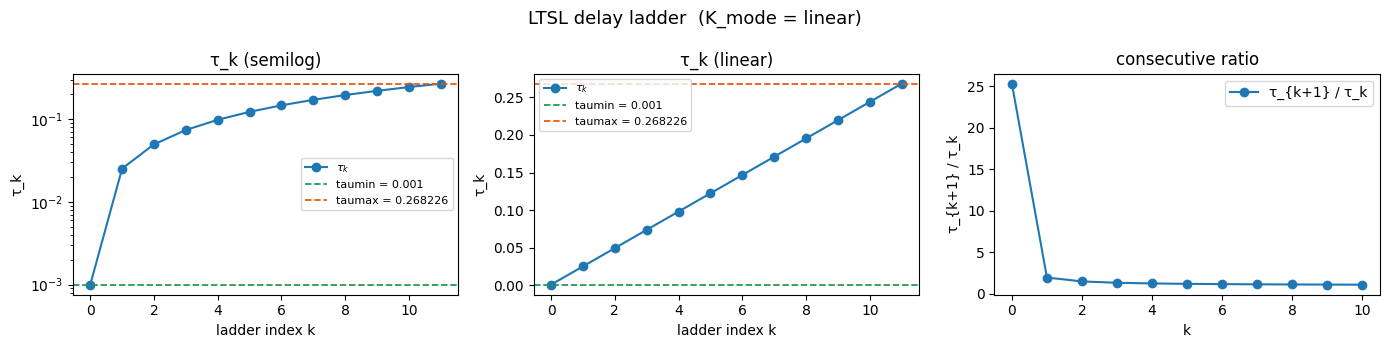

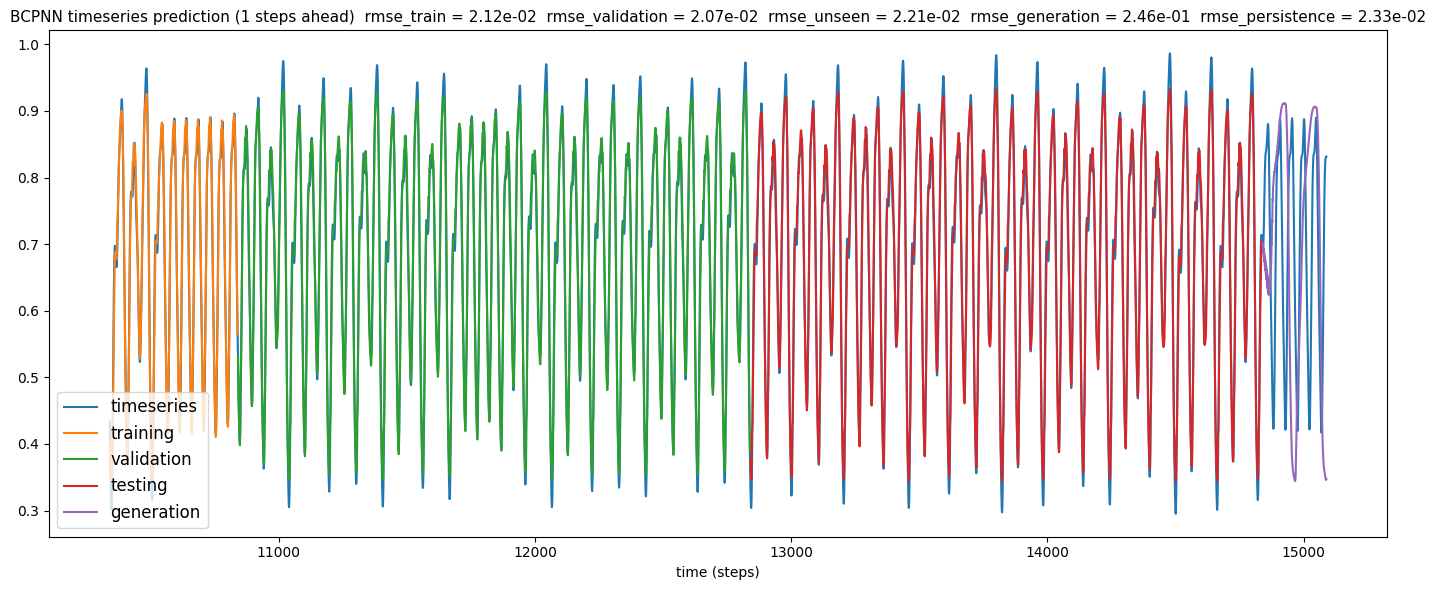

In [ ]:
# --- Cell: Run LTSL with EA-optimized hyperparameters (offs=1, rmse_unseen) ---
# Applies best parameters from a 20 h evolutionary search, writes Parameters.par,
# plots the delay ladder, and runs Mains.general to obtain RMSE metrics.
#best setup to minimize rmse_unseen at offs=1 according to the evolutionary algorithm after 20h search
"""
#offs=1 !!!
Wide parameter space and long run AFTER the METRIC FIX, seperately validated on 2000 unseen samples now                                                                           
python3 evolve_hyperparams.py --objective rmse_validation --time 78120 --K 2 25 --K_mode linear logarithmic --mean_nbin 10 80 --deriv1st_nbin 10 80 --taumax 0.002 2.0  --trnpat 5000 15000                                    

=== Best after SHORT time budget ===                                                                                     │   3224  4:35.13  20  0.0   0.0  598M 44968 34416 S fiebig       0 /usr/bin/update-notifier         
  objective       = rmse_validation                                                                                │   1708  4:31.46  20  0.0   0.0  328M 20372 16588 S root         0 /usr/sbin/NetworkManager --no-dae
  K               = 12                                                                                             │   1631  4:16.94  20  0.0   0.0 18260 11596  9868 S root         0 /usr/sbin/wpa_supplicant -u -s -O
  K_mode          = linear                                                                                         │   2885  4:15.43  20  0.0   0.0  541M 14908 12084 S fiebig       0 /usr/libexec/xdg-desktop-portal  
  mean_nbin       = 19                                                                                             │   4619  4:09.06  20  0.0   0.0  639M 48796 39240 S root         0 /usr/libexec/fwupd/fwupd         
  deriv1st_nbin   = 42                                                                                             │   1706  3:44.51  20  0.0   0.0  328M 20372 16588 S root         0 /usr/sbin/NetworkManager --no-dae
  taumax          = 0.9616636974859427                                                                             │   2339  3:22.25  20  0.2   0.0 4438M  454M  186M S fiebig       0 /usr/bin/gnome-shell             
  trnpat          = 7455                                                                                           │   1528  3:15.92  20  0.0   0.0  458M 15700 11640 S root         0 /usr/libexec/udisks2/udisksd     
  outagain_gen    = 0.015495837337447908                                                                           │   2016  3:02.39  20  0.0   0.0 24.2G 86384 58472 S fiebig       0 /usr/lib/xorg/Xorg vt2 -displayfd
  rmse_validation (minimized) = 0.02751329377272139                                                                │   1932  2:51.03  20  0.0   0.0 11140  6988  4772 S fiebig       0 /usr/bin/dbus-daemon --session --
  rmse_train      = 0.02786562909167652                                                                            │ 975400  2:49.98  20  0.2   0.0 7282M  630M  123M S fiebig       0 /home/fiebig/.dropbox-dist/dropbo
  rmse_unseen = 0.02751329377272139                                                                                │ 975401  2:49.61  20  0.2   0.0 7282M  630M  123M S fiebig       0 /home/fiebig/.dropbox-dist/dropbo
  rmse_unseen     = 0.027746271962304402                                                                           │ 975403  2:49.58  20  0.2   0.0 7282M  630M  123M S fiebig       0 /home/fiebig/.dropbox-dist/dropbo
  rmse_generation = nan                                                                                            │ 975402  2:48.92  20  0.2   0.0 7282M  630M  123M S fiebig       0 /home/fiebig/.dropbox-dist/dropbo
  rmse_persistence = 0.031392717394389674  (naive y_t -> y_{t+offs}=y_t baseline; any model worth its salt should b│   4618  2:42.99  20  0.0   0.0  639M 48796 39240 S root         0 /usr/libexec/fwupd/fwupd         
eat this)                    
 
        === Best after LONG time budget ===                                                                                        │
          objective       = rmse_unseen                                                                                   │
          K               = 8                                                                                                 │
          K_mode          = linear                                                                                            │
          mean_nbin       = 16                                                                                                │
          deriv1st_nbin   = 18                                                                                                │
          taumax          = 0.26822566930621056                                                                               │
          trnpat          = 10840                                                                                             │
          outagain_gen    = 22.55919961341915      #not meaningful because generation was not part of the EA optimization                                                                           │
          rmse_unseen (minimized) = 0.025479335052601634                                                                  │
          rmse_train      = 0.026255258831391386                                                                              │
          rmse_unseen = 0.025479335052601634                                                                              │
          rmse_unseen     = 0.02667124469610807                                                                               │
          rmse_generation = nan                                                                                               │
          rmse_persistence = 0.03143477771540331 






"MG data normaization after has pushed RMSE further down after this EA search"

"""

import importlib
import Utils, Mains, Display
importlib.reload(Utils)
importlib.reload(Mains)
importlib.reload(Display)
# Load, modify, write


params = Utils.load_params("Parameters_default.par")
params["timeseries_file"] = "mgdata.pkl"#"sosdata.pkl"
params["offs"] = 1                  #1
params["tmax"] = 200000              #200000 default
params["K"] = 12                    #8 of up to 25
params["K_mode"] = "linear"         #linear (best after evo search)
params["mean_nbin"] = 16            #16 of up to 80        
params["deriv1st_nbin"] = 18        #18 of up to 80  
params["taumax"] = 0.26822566930621056 #of up to 2.
params["trnpat"] = 10840             #10840 of up to 15000
params["vanpat"] = 2000              #2000 (2000 during evo search)
params["tenpat"] = 2000              #2000
params["ngenstep"] =250             #not evaluated by evo search, but worse in linear mode

Utils.write_params("Parameters.par", params)
fig = Display.plot_ltsl_delay_ladder("Parameters.par", verbose=True)
rmse_train, rmse_validation, rmse_unseen, rmse_generation, rmse_persistence = Mains.general(figno = 1, verbose=True, data_plot_start=params["trnpat"]-500)

In [2]:
# --- Cell: Utility — seconds in 24 hours (86400) ---
# Reference value used when setting --time for evolve_hyperparams.py.
3600*24



86400

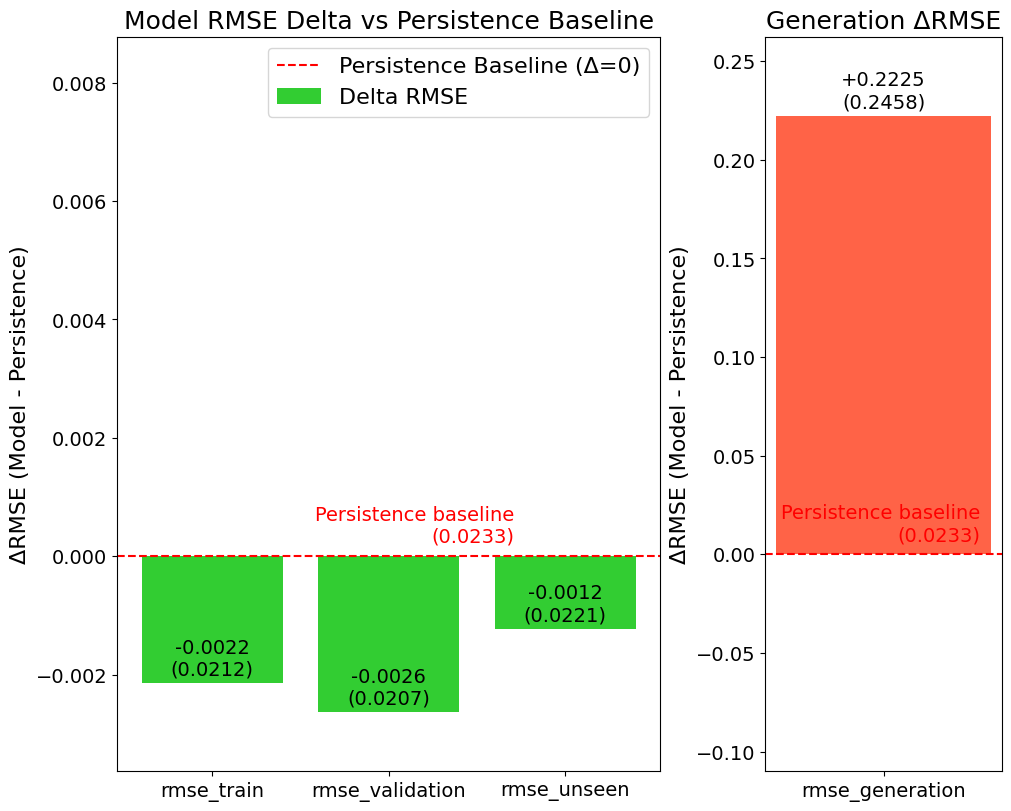

In [22]:
# --- Cell: Visualize RMSE improvement over persistence baseline ---
# Bar charts of delta-RMSE (model minus persistence) for train, validation,
# unseen, and generation splits. Green = beats persistence; red = worse.
import matplotlib.pyplot as plt
import numpy as np

# Compute delta RMSE (model - persistence)
metrics_main = ['rmse_train', 'rmse_validation', 'rmse_unseen']
values_main = [rmse_train, rmse_validation, rmse_unseen]
deltas_main = [v - rmse_persistence for v in values_main]

metric_gen = ['rmse_generation']
value_gen = [rmse_generation]
delta_gen = [rmse_generation - rmse_persistence]

# Increase fontsize by two steps
label_fontsize = 16  # default is around 12
tick_fontsize = 14   # default is around 10
title_fontsize = 18  # default is around 14
annot_fontsize = 14  # default is around 10-12

fig, (ax, ax_gen) = plt.subplots(1, 2, figsize=(10,8), gridspec_kw={'width_ratios': [2.3, 1]}, constrained_layout=True)

# Left plot: training, validation, unseen deltas vs persistence
bars = ax.bar(metrics_main, deltas_main, color=np.where(np.array(deltas_main)<0, 'limegreen', 'tomato'), label='Delta RMSE')
# Dashed gray line at zero (persistence baseline)
ax.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Persistence Baseline (Δ=0)')
ax.set_ylabel('ΔRMSE (Model - Persistence)', fontsize=label_fontsize)
ax.set_title('Model RMSE Delta vs Persistence Baseline', fontsize=title_fontsize)
ax.legend(fontsize=label_fontsize)
ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
for bar, v, d in zip(bars, values_main, deltas_main):
    height = bar.get_height()
    ax.annotate(f"{d:+.4f}\n({v:.4f})", xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=annot_fontsize)

ax.annotate(f"Persistence baseline\n({rmse_persistence:.4f})", 
            xy=(len(values_main)-0.5, 0), 
            xytext=(-100,10), textcoords='offset points', color='red', ha='right', fontsize=annot_fontsize)
ax.set_ylim(min(deltas_main)-0.001, max(deltas_main)+0.01)

# Right plot: generation delta vs persistence
bar_gen = ax_gen.bar(metric_gen, delta_gen, color=['limegreen' if delta_gen[0]<0 else 'tomato'], label='Delta Generation RMSE')
# Dashed gray line at zero (persistence baseline)
ax_gen.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Persistence Baseline (Δ=0)')
ax_gen.set_ylabel('ΔRMSE (Model - Persistence)', fontsize=label_fontsize)
ax_gen.set_title('Generation ΔRMSE', fontsize=title_fontsize)
ax_gen.tick_params(axis='both', which='major', labelsize=tick_fontsize)
for bar, v, d in zip(bar_gen, value_gen, delta_gen):
    height = bar.get_height()
    ax_gen.annotate(f"{d:+.4f}\n({v:.4f})", xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=annot_fontsize)

ax_gen.annotate(f"Persistence baseline\n({rmse_persistence:.4f})", 
                xy=(0, 0), 
                xytext=(70,10), textcoords='offset points', color='red', ha='right', fontsize=annot_fontsize)

ax_gen.set_ylim(-0.11, delta_gen[0]+0.04)
plt.show()

In [ ]:
# --- Cell: (empty spacer) ---


0.0625

K_mode=linear, c=None, τ_0=0.001, τ_11=0.26822566930621056
Using data from /home/fiebig/Dropbox/GIT/BCPNNSim2.2_UC2/tests/UC2-EXTRABRAIN/LTSLtest/general/datasets/mgdata.pkl (timeseries_tmax=20000, requested_tmax=20000)


Hj = 1 nactHi = 12 nsilHi = 0 denHi = 12 Mi = 288 denNi = 3456


paramfile = Parameters.par
taup = 10.840
eps = 9.2e-05
K_mode = linear
TRAINING from simstep = 0 offs = 10
setinputime elapsed = 0.726 sec
TESTING on training data from simstep = 10830
VALIDATING on held-out data from simstep = 21660
TESTING on unseen data from simstep = 23650

GENERATING from simstep = 25640
Total simsteps = 25890, time elapsed = 25.887 sec
  rmse_train       = 0.063178
  rmse_validation  = 0.064059
  rmse_unseen      = 0.063628
  rmse_generation  = 0.20167
  rmse_persistence = 0.20308  (naive y_t -> y_{t+10}=y_t baseline over post-train window)


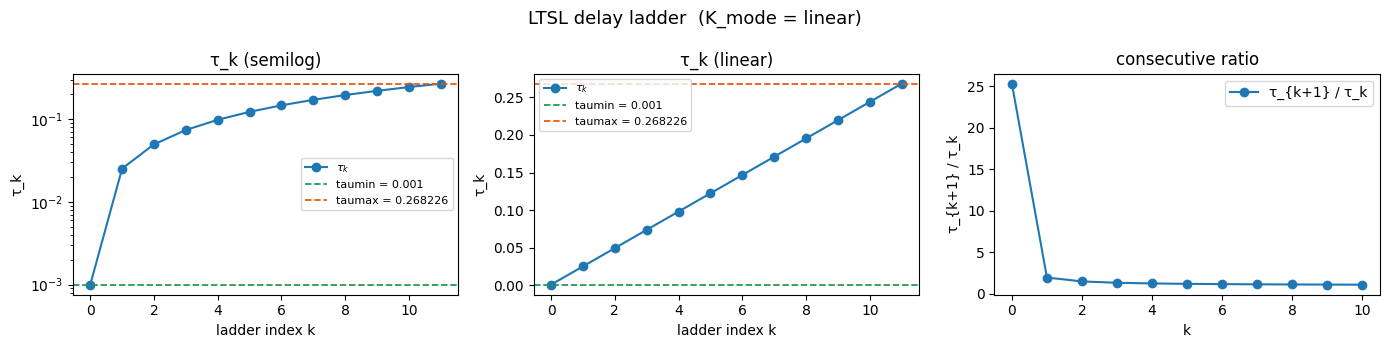

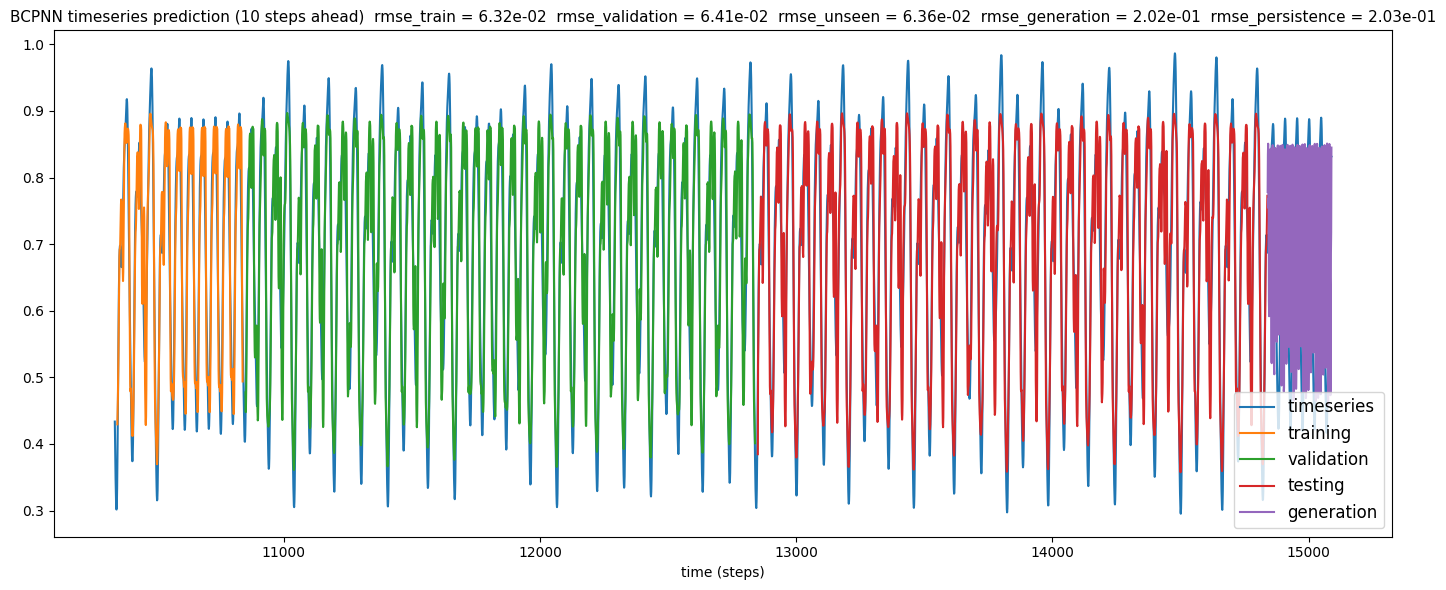

In [ ]:
# --- Cell: Run LTSL with same EA params but offs=10 (10-step prediction) ---
# Reuses the optimized hyperparameters from the offs=1 search but sets the
# prediction horizon to 10 steps ahead to score longer-range forecasting.
#best setup to minimize rmse_unseen at offs=1 according to the evolutionary algorithm after 20h search
"""
scoring the 10 step prediction
"""

import importlib
import Utils, Mains, Display
importlib.reload(Utils)
importlib.reload(Mains)
importlib.reload(Display)
# Load, modify, write
params = Utils.load_params("Parameters_default.par")
params["timeseries_file"] = "mgdata.pkl"#"sosdata.pkl"
params["offs"] = 10                  #1
params["tmax"] = 20000              #20000 default
params["K"] = 12                    #8 of up to 25
params["K_mode"] = "linear"         #linear (best after evo search)
params["mean_nbin"] = 16            #16 of up to 80        
params["deriv1st_nbin"] = 18        #18 of up to 80  
params["taumax"] = 0.26822566930621056 #of up to 2.
params["trnpat"] = 10840             #10840 of up to 15000
params["vanpat"] = 2000              #2000 (2000 during evo search)
params["tenpat"] = 2000              #2000
params["ngenstep"] =250             #not evaluated by evo search, but worse in linear mode

Utils.write_params("Parameters.par", params)
fig = Display.plot_ltsl_delay_ladder("Parameters.par", verbose=True)
rmse_train, rmse_validation, rmse_unseen, rmse_generation, rmse_persistence = Mains.general(figno = 1, verbose=True, data_plot_start=params["trnpat"]-500)

Parameter sweep: 50 combinations to run


  [1/50] {'offs': 1, 'K': 1, 'K_mode': 'linear', 'mean_nbin': 16, 'deriv1st_nbin': 18, 'taumax': 0.26822566930621056, 'trnpat': 10840} -> rmse_unseen = 2.5730e-02  (6.0s, ~4m54s left)
  [2/50] {'offs': 1, 'K': 1, 'K_mode': 'logarithmic', 'mean_nbin': 16, 'deriv1st_nbin': 18, 'taumax': 0.26822566930621056, 'trnpat': 10840} -> rmse_unseen = 2.5730e-02  (5.7s, ~4m41s left)
  [3/50] {'offs': 1, 'K': 2, 'K_mode': 'linear', 'mean_nbin': 16, 'deriv1st_nbin': 18, 'taumax': 0.26822566930621056, 'trnpat': 10840} -> rmse_unseen = 2.4557e-02  (9.4s, ~5m31s left)
  [4/50] {'offs': 1, 'K': 2, 'K_mode': 'logarithmic', 'mean_nbin': 16, 'deriv1st_nbin': 18, 'taumax': 0.26822566930621056, 'trnpat': 10840} -> rmse_unseen = 2.4557e-02  (8.6s, ~5m42s left)
  [5/50] {'offs': 1, 'K': 3, 'K_mode': 'linear', 'mean_nbin': 16, 'deriv1st_nbin': 18, 'taumax': 0.26822566930621056, 'trnpat': 10840} -> rmse_unseen = 2.3682e-02  (9.7s, ~5m55s left)
  [6/50] {'offs': 1, 'K': 3, 'K_mode': 'logarithmic', 'mean_nbin': 16,

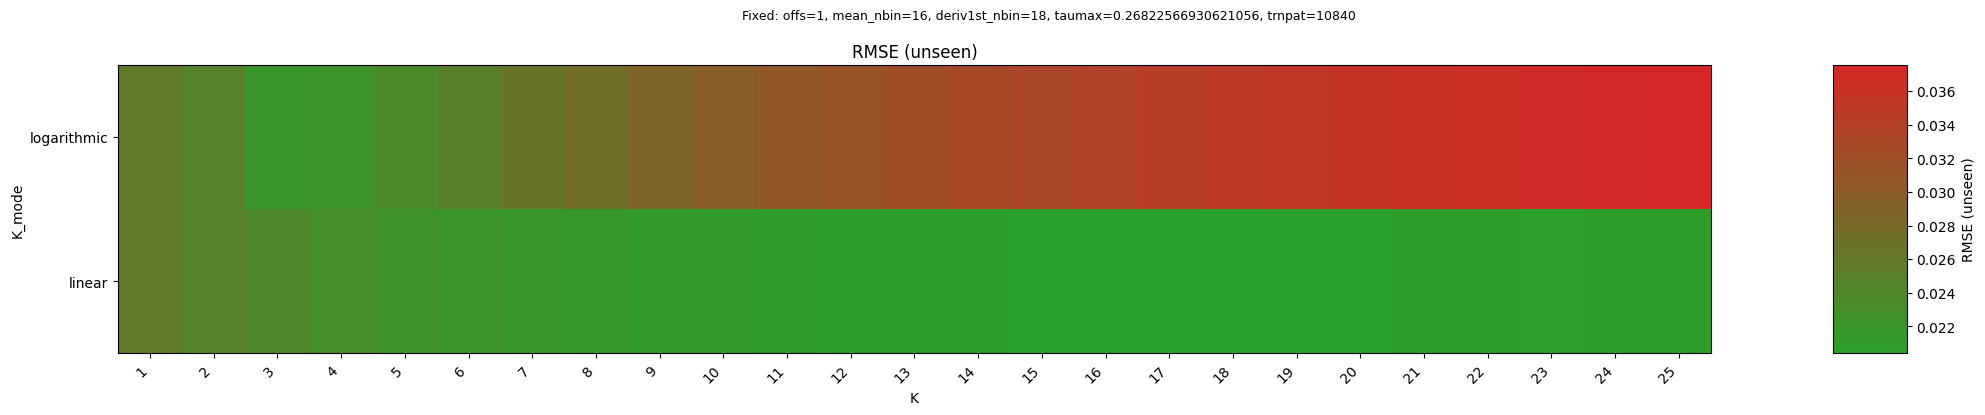

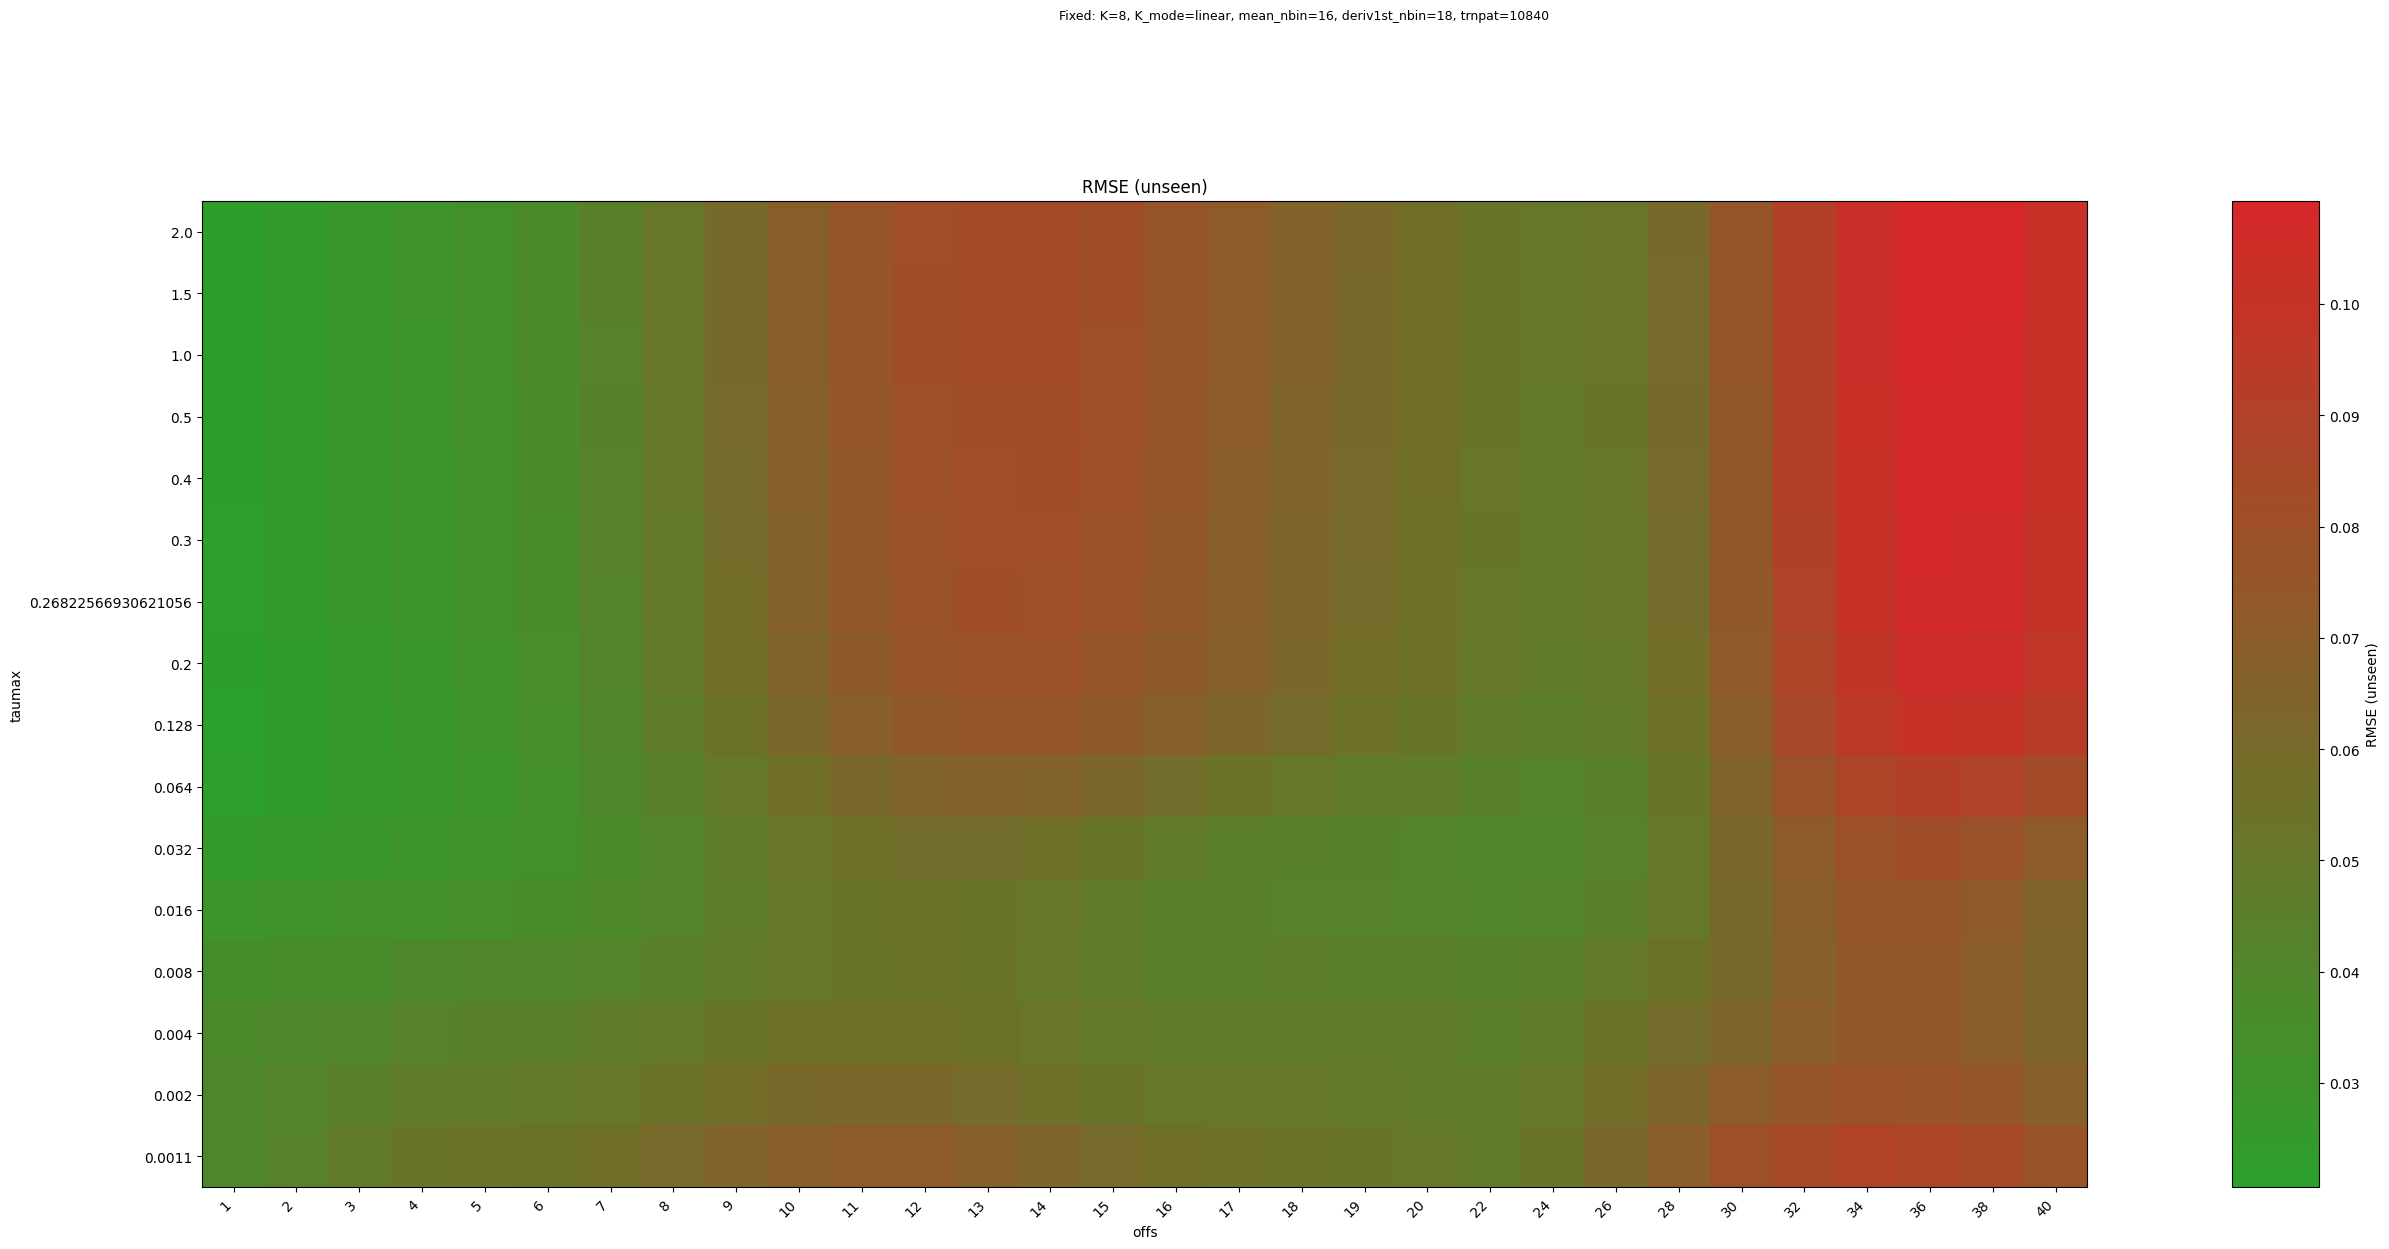

In [ ]:
# --- Cell: Parameter sweeps — 2D heatmaps (computationally expensive) ---
# Sweeps K x K_mode and offs x taumax around the EA optimum; saves heatmaps to
# figs/1_mg_rmse_unseen/. Many 1D sweeps are commented out above for reference.
#0.02667124469610807 error on the unseen set
import importlib
import Utils, Mains, Display
importlib.reload(Utils)
importlib.reload(Mains)
importlib.reload(Display)
"""
sweep_spec = { # --- Define parameter values to sweep  ---
   "offs":           [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,22,24,26,28,30,32,34,36,38,40], #Next day prediction and beyond
    "K":             [8], #8 best from evo search: 2-25
    "K_mode":        ["linear"], #new linear mode best after EVO
    "mean_nbin":     [16], #range from evo search:  2-80
    "deriv1st_nbin": [18], #range from evo search:  2-80
    "taumax":        [0.26822566930621056], #range from evo search: 0.00101-2.  
    "trnpat":        [10840], #range from evo search: 500-15000
}
results = Utils.param_sweep(sweep_spec,default_paramfile="Parameters_default.par",paramfile="Parameters.par",run_fn=Mains.general,run_kwargs={"figno": 0, "verbose": False})
Display.plot_sweep_heatmaps(results, sweep_spec, savepath="figs/1_mg_rmse_unseen/")

sweep_spec = { # --- Define parameter values to sweep  ---
   "offs":           [1], #Next day prediction
    "K":             [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25], #8 best from evo search: 2-25
    "K_mode":        ["linear"], #new linear mode best after EVO
    "mean_nbin":     [16], #range from evo search:  2-80
    "deriv1st_nbin": [18], #range from evo search:  2-80
    "taumax":        [0.26822566930621056], #range from evo search: 0.00101-2.  
    "trnpat":        [10840], #range from evo search: 500-15000
}
results = Utils.param_sweep(sweep_spec,default_paramfile="Parameters_default.par",paramfile="Parameters.par",run_fn=Mains.general,run_kwargs={"figno": 0, "verbose": False})
Display.plot_sweep_heatmaps(results, sweep_spec, savepath="figs/1_mg_rmse_unseen/")

sweep_spec = { # --- Define parameter values to sweep  ---
   "offs":           [1], #Next day prediction
    "K":             [8], #8 best from evo search: 2-25
    "K_mode":        ["linear","logarithmic"], #new linear mode best after EVO
    "mean_nbin":     [16], #range from evo search:  2-80
    "deriv1st_nbin": [18], #range from evo search:  2-80
    "taumax":        [0.26822566930621056], #range from evo search: 0.00101-2.  
    "trnpat":        [10840], #range from evo search: 500-15000
}
results = Utils.param_sweep(sweep_spec,default_paramfile="Parameters_default.par",paramfile="Parameters.par",run_fn=Mains.general,run_kwargs={"figno": 0, "verbose": False})
Display.plot_sweep_heatmaps(results, sweep_spec, savepath="figs/1_mg_rmse_unseen/")

sweep_spec = { # --- Define parameter values to sweep  ---
   "offs":           [1], #Next day prediction
    "K":             [8], #8 best from evo search: 2-25
    "K_mode":        ["linear"], #new linear mode best after EVO
    "mean_nbin":     [2,4,6,8,10,12,16,32,64,80], #range from evo search:  2-80
    "deriv1st_nbin": [18], #range from evo search:  2-80
    "taumax":        [0.26822566930621056], #range from evo search: 0.00101-2.  
    "trnpat":        [10840], #range from evo search: 500-15000
}
results = Utils.param_sweep(sweep_spec,default_paramfile="Parameters_default.par",paramfile="Parameters.par",run_fn=Mains.general,run_kwargs={"figno": 0, "verbose": False})
Display.plot_sweep_heatmaps(results, sweep_spec, savepath="figs/1_mg_rmse_unseen/")

sweep_spec = { # --- Define parameter values to sweep  ---
   "offs":           [1], #Next day prediction
    "K":             [8], #8 best from evo search: 2-25
    "K_mode":        ["linear"], #new linear mode best after EVO
    "mean_nbin":     [16], #range from evo search:  2-80
    "deriv1st_nbin": [2,4,6,8,10,14,18,32,64,80], #range from evo search:  2-80unseen
    "taumax":        [0.26822566930621056], #range from evo search: 0.00101-2.  
    "trnpat":        [10840], #range from evo search: 500-15000
}
results = Utils.param_sweep(sweep_spec,default_paramfile="Parameters_default.par",paramfile="Parameters.par",run_fn=Mains.general,run_kwargs={"figno": 0, "verbose": False})
Display.plot_sweep_heatmaps(results, sweep_spec, savepath="figs/1_mg_rmse_unseen/")

sweep_spec = { # --- Define parameter values to sweep  ---
   "offs":           [1], #Next day prediction
    "K":             [8], #8 best from evo search: 2-25
    "K_mode":        ["linear"], #new linear mode best after EVO
    "mean_nbin":     [16], #range from evo search:  2-80
    "deriv1st_nbin": [18], #range from evo search:  2-80
    "taumax":        [0.0011,0.002,0.004,0.008,0.016,0.032,0.064,0.128,0.26822566930621056,0.5,1.,1.5,2.], #range from evo search: 0.00101-2.  
    "trnpat":        [10840], #range from evo search: 500-15000
}
results = Utils.param_sweep(sweep_spec,default_paramfile="Parameters_default.par",paramfile="Parameters.par",run_fn=Mains.general,run_kwargs={"figno": 0, "verbose": False})
Display.plot_sweep_heatmaps(results, sweep_spec, savepath="figs/1_mg_rmse_unseen/")

sweep_spec = { # --- Define parameter values to sweep  ---
   "offs":           [1], #Next day prediction
    "K":             [8], #8 best from evo search: 2-25
    "K_mode":        ["linear"], #new linear mode best after EVO
    "mean_nbin":     [16], #range from evo search:  2-80
    "deriv1st_nbin": [18], #range from evo search:  2-80
    "taumax":        [0.26822566930621056], #range from evo search: 0.00101-2.  
    "trnpat":        [500,1000,2000,3000,4000,5000,6000,7000,8000,9000,10000,10800,10800,10820,10840,10860,10880,10900,12000,13000,14000], #range from evo search: 500-15000
}
results = Utils.param_sweep(sweep_spec,default_paramfile="Parameters_default.par",paramfile="Parameters.par",run_fn=Mains.general,run_kwargs={"figno": 0, "verbose": False})
Display.plot_sweep_heatmaps(results, sweep_spec, savepath="figs/1_mg_rmse_unseen/")
"""

#add some interesting (but 2h expensive) 2D plots

sweep_spec = { # --- Define parameter values to sweep  ---
   "offs":           [1], #Next day prediction
    "K":             [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25], #8 best from evo search: 2-25
    "K_mode":        ["linear","logarithmic"], #new linear mode best after EVO
    "mean_nbin":     [16], #range from evo search:  2-80
    "deriv1st_nbin": [18], #range from evo search:  2-80
    "taumax":        [0.26822566930621056], #range from evo search: 0.00101-2.  
    "trnpat":        [10840], #range from evo search: 500-15000
}
results = Utils.param_sweep(sweep_spec,default_paramfile="Parameters_default.par",paramfile="Parameters.par",run_fn=Mains.general,run_kwargs={"figno": 0, "verbose": False})
Display.plot_sweep_heatmaps(results, sweep_spec, savepath="figs/1_mg_rmse_unseen/")

sweep_spec = { # --- Define parameter values to sweep  ---
   "offs":           [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,22,24,26,28,30,32,34,36,38,40], #Next day prediction and beyond
    "K":             [8], #8 best from evo search: 2-25
    "K_mode":        ["linear"], #new linear mode best after EVO
    "mean_nbin":     [16], #range from evo search:  2-80
    "deriv1st_nbin": [18], #range from evo search:  2-80
    "taumax":        [0.0011,0.002,0.004,0.008,0.016,0.032,0.064,0.128,0.2,0.26822566930621056,0.3,0.4,0.5,1.,1.5,2.], #range from evo search: 0.00101-2.  
    "trnpat":        [10840], #range from evo search: 500-15000
}
results = Utils.param_sweep(sweep_spec,default_paramfile="Parameters_default.par",paramfile="Parameters.par",run_fn=Mains.general,run_kwargs={"figno": 0, "verbose": False})
Display.plot_sweep_heatmaps(results, sweep_spec, savepath="figs/1_mg_rmse_unseen/")




K_mode=logarithmic, c=1.7075433512279106, τ_0=0.001, τ_12=0.6144136572881429
Using data from /home/fiebig/Dropbox/GIT/BCPNNSim2.2_UC2/tests/UC2-EXTRABRAIN/LTSLtest/general/datasets/mgdata.pkl (timeseries_tmax=20000, requested_tmax=20000)


Hj = 1 nactHi = 13 nsilHi = 0 denHi = 13 Mi = 3710 denNi = 48230


paramfile = Parameters.par
taup = 5.164
eps = 1.9e-04
K_mode = logarithmic
TRAINING from simstep = 0 offs = 1
setinputime elapsed = 2.253 sec
TESTING on training data from simstep = 5163
VALIDATING on held-out data from simstep = 10326
TESTING on unseen data from simstep = 12325

GENERATING from simstep = 14324
Total simsteps = 14574, time elapsed = 169.071 sec
  rmse_train       = 0.026106
  rmse_validation  = 0.026259
  rmse_unseen      = 0.02596
  rmse_generation  = 0.21902
  rmse_persistence = 0.023308  (naive y_t -> y_{t+1}=y_t baseline over post-train window)


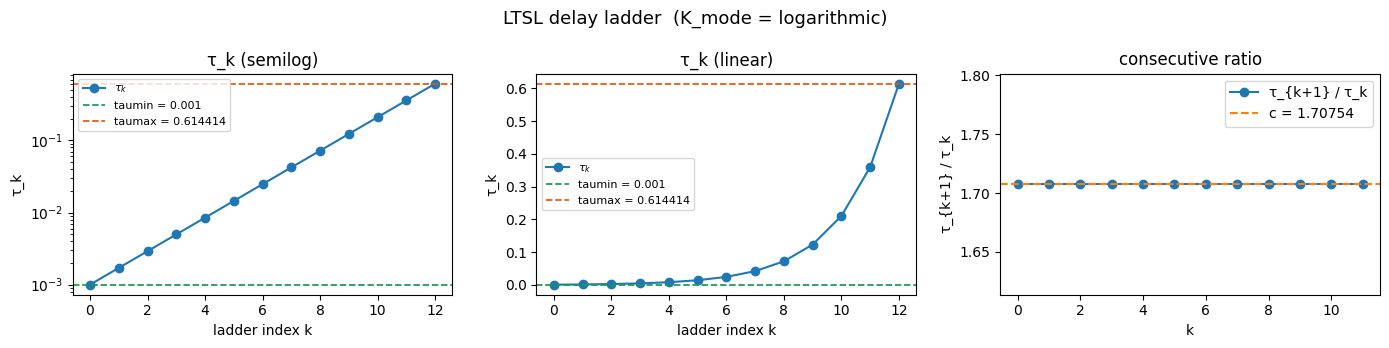

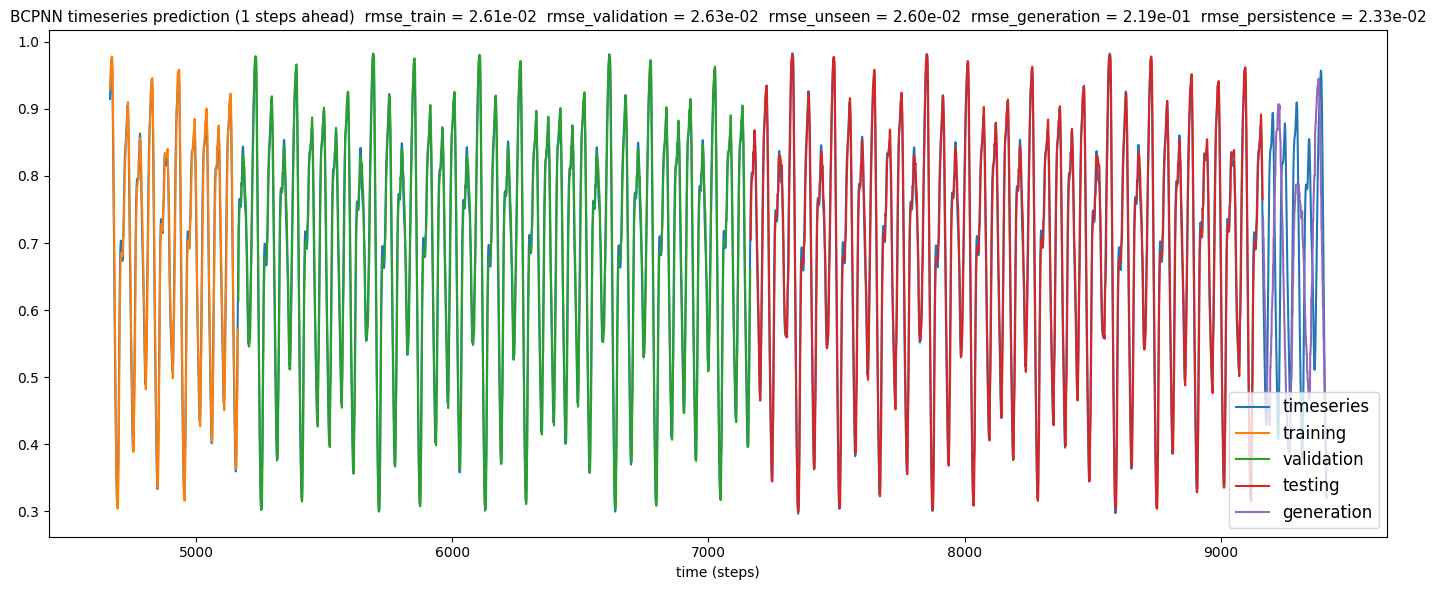

In [ ]:
# --- Cell: Alternative EA result — logarithmic K_mode ---
# Runs LTSL with hyperparameters from a separate EA search using logarithmic
# delay spacing and a validation objective (24 h budget).
"""
making an attempt at doing al of this logarithmically probably cheaper, and perhaps even better


python3 evolve_hyperparams.py --obj│
ective rmse_validation --time 86400 --K 2 25 --K_mode logarithmic --mean_nbin 10 100 --deriv1st_nbin 10 100 --taumax 0│
.002 2.0  --trnpat 2000 150000 
 

=== Best after SHORT time budget ===                                                           │
  objective       = rmse_validation                                                      │
  K               = 13                                                                   │
  K_mode          = logarithmic                                                          │
  mean_nbin       = 53                                                                   │
  deriv1st_nbin   = 70                                                                   │
  taumax          = 0.6144136572881431                                                   │
  trnpat          = 5164                                                                 │
  outagain_gen    = 30.827908688835173                                                   │
  rmse_validation (minimized) = 0.031005026822208317                                     │
  rmse_train      = 0.03020732441142313                                                  │
  rmse_validation = 0.031005026822208317                                                 │
  rmse_unseen     = 0.030177600801250638                                                 │
  rmse_generation = nan                                                                  │
  rmse_persistence = 0.22941236581082738

    === Best after LONG time budget, allowing for 100 bins and vastly more training data===      

"""

import importlib
import Utils, Mains, Display
importlib.reload(Utils)
importlib.reload(Mains)
importlib.reload(Display)
# Load, modify, write
params = Utils.load_params("Parameters_default.par")
params["timeseries_file"] = "mgdata.pkl"#"sosdata.pkl"
params["offs"] = 1                
params["tmax"] = 20000            
params["K"] = 13                   
params["K_mode"] = "logarithmic"  
params["mean_nbin"] = 53         
params["deriv1st_nbin"] = 70      
params["taumax"] = 0.6144136572881431            
params["outagain_gen"] = 30.827908688835173             
params["trnpat"] = 5164         
params["tenpat"] = 2000          
params["ngenstep"] = 250         
Utils.write_params("Parameters.par", params)
fig = Display.plot_ltsl_delay_ladder("Parameters.par", verbose=True)
rmse_train, rmse_validation, rmse_unseen, rmse_generation, rmse_persistence = Mains.general(figno = 1, verbose=True, data_plot_start=params["trnpat"]-500)


K_mode=logarithmic, c=1.6838362584267463, τ_0=0.001, τ_13=0.8747785826459774
Using data from /home/fiebig/Dropbox/GIT/BCPNNSim2.2_UC2/tests/UC2-EXTRABRAIN/LTSLtest/general/datasets/mgdata.pkl (timeseries_tmax=20000, requested_tmax=20000)


Hj = 1 nactHi = 14 nsilHi = 0 denHi = 14 Mi = 216 denNi = 3024


paramfile = Parameters.par
taup = 10.782
eps = 9.3e-05
K_mode = logarithmic
TRAINING from simstep = 0 offs = 1
setinputime elapsed = 0.628 sec
TESTING on training data from simstep = 10781

GENERATING from simstep = 21562
Total simsteps = 21812, time elapsed = 15.277 sec
  rmse_train       = 0.03922
  rmse_validation  = nan
  rmse_unseen      = nan
  rmse_generation  = 0.16889
  rmse_persistence = 0.031797  (naive y_t -> y_{t+1}=y_t baseline over post-train window)


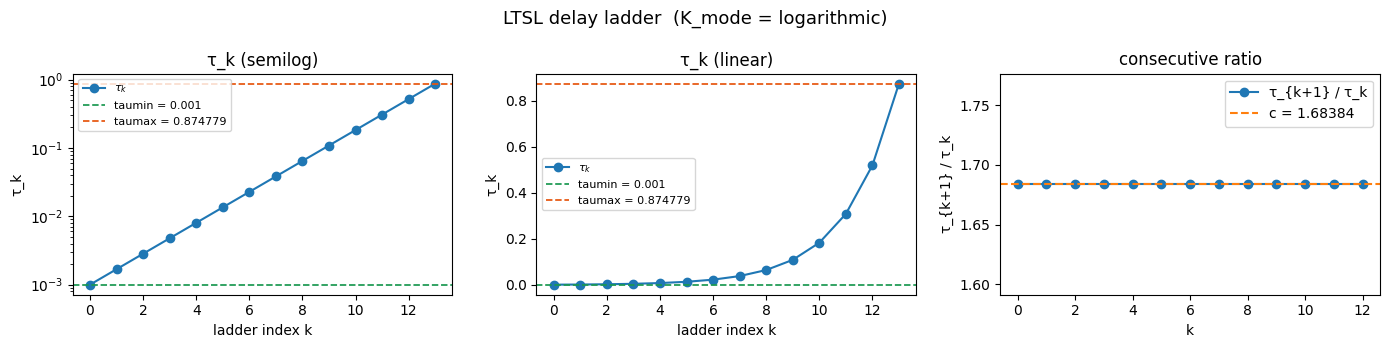

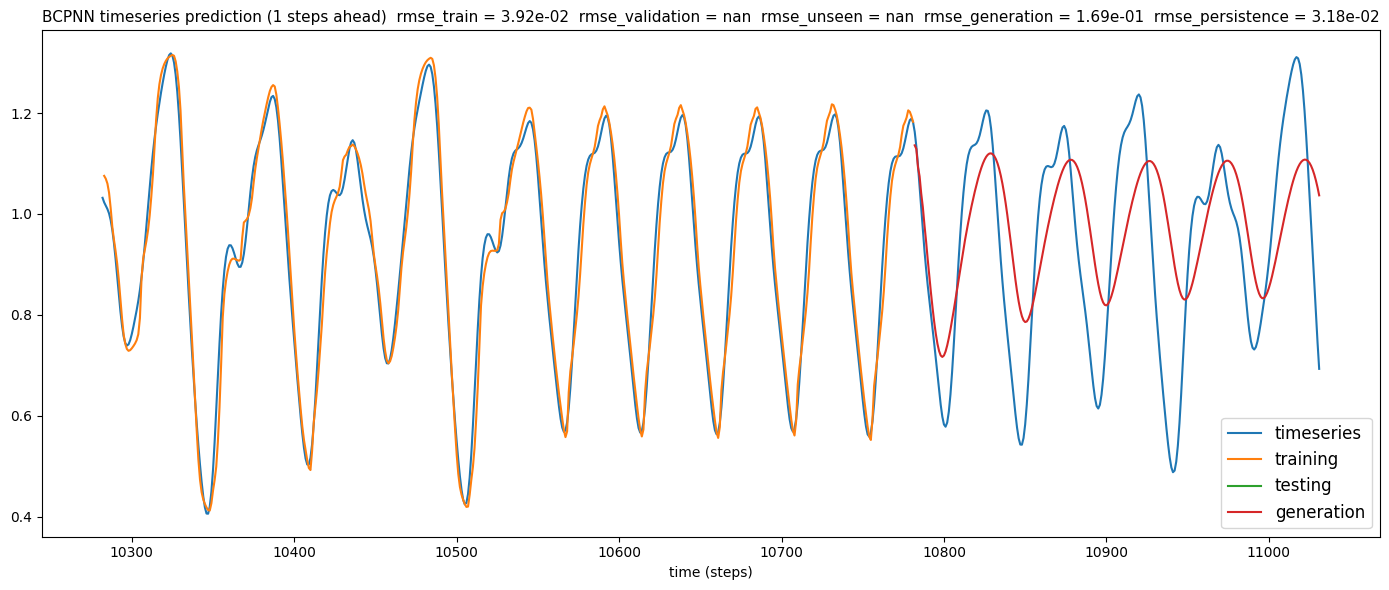

In [1]:
# --- Cell: EA-optimized for rmse_generation (offs=1, 1 h search) ---
# Configuration tuned to minimize generation-set RMSE rather than unseen RMSE;
# uses logarithmic K_mode and a specific outagain_gen value.
#best setup to minimize rmse_generation at offs=1 according to the evolutionary algorithm after 1h search
"""
#offs=1 !!! short search

#DELELTE VALIDATION, SET GENERATION before running this                                                                                

python3 evolve_hyperparams.py --│
objective rmse_generation --time 29000 --K 2 20 --K_mode linear logarithmic --mean_nbin 5 40 --deriv1st_nbin 5 40 -│
-taumax 0.002 2.0  --trnpat 5000 15000 --outagain_gen .1 10                         

=== Best after time budget ===                                                                      │
  objective       = rmse_generation                                                                 │
  K               = 14                                                                              │
  K_mode          = logarithmic                                                                     │
  mean_nbin       = 18                                                                              │
  deriv1st_nbin   = 12                                                                              │
  taumax          = 0.8747785826459769                                                              │
  trnpat          = 10782                                                                           │
  outagain_gen    = 0.24578880518345353                                                             │
  rmse_generation (minimized) = 0.13663916456248315                                                 │
  rmse_train      = 0.03922028809697925                                                             │
  rmse_validation = 0.039388487079573445                                                            │
  rmse_unseen     = 0.03903624000879022                                                             │
  rmse_generation = 0.13663916456248315                                                             │
  rmse_persistence = 0.03142905474741532
  """
import importlib
import Utils, Mains, Display
importlib.reload(Utils)
importlib.reload(Mains)
importlib.reload(Display)
# Load, modify, write
params = Utils.load_params("Parameters_default.par")
params["timeseries_file"] = "mgdata.pkl"#"sosdata.pkl"
params["offs"] = 1                
params["tmax"] = 20000            
params["K"] = 14                   
params["K_mode"] = "logarithmic"  
params["mean_nbin"] = 18         
params["deriv1st_nbin"] = 12      
params["taumax"] = 0.8747785826459769            
params["outagain_gen"] = 0.24578880518345353                 
params["trnpat"] = 10782         
params["tenpat"] = 0          
params["ngenstep"] = 250         
Utils.write_params("Parameters.par", params)
fig = Display.plot_ltsl_delay_ladder("Parameters.par", verbose=True)
rmse_train, rmse_validation, rmse_unseen, rmse_generation, rmse_persistence = Mains.general(figno = 1, verbose=True, data_plot_start=params["trnpat"]-500)

In [ ]:
# --- Cell: (empty placeholder) ---
